# Let's ask questions

Time for some AI magic. Instead of just demanding accuracy we think like journalists: the goal is to **make verification as simple as possible.**

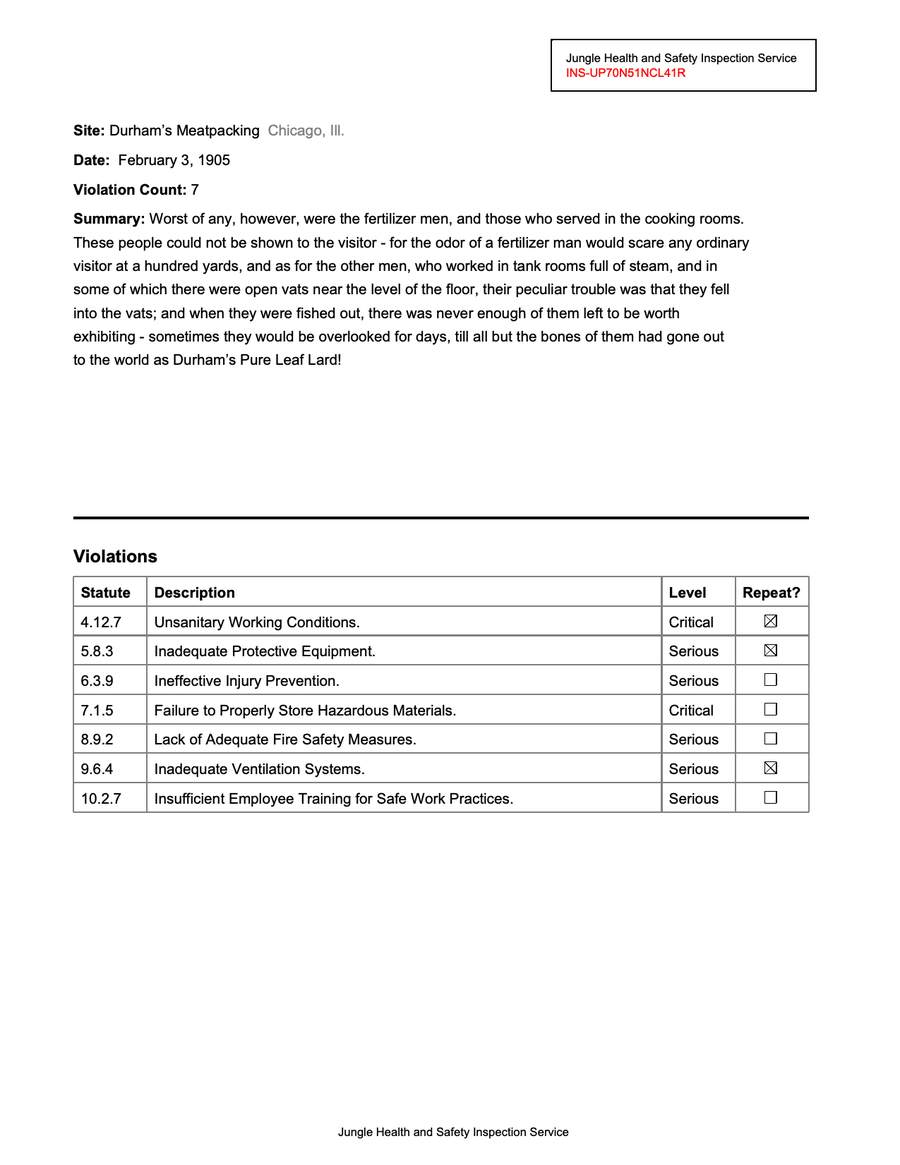

In [7]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/01-practice.pdf")
page = pdf.pages[0]
page.show(width=900)

## Structured data generation

Usually if it's just a specific piece of text you're looking for, you can use spatial commands to pull it out. The times that LLMs come in handy is when there's a bit of nuance in your question (or the answer). You want it to write things that aren't in there, or piece together something complicated. It's worth the potential for hallucinations!

Below we're using Google thanks to its [OpenAI compatibility](https://ai.google.dev/gemini-api/docs/openai).

In [8]:
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY") or input("Enter GOOGLE_API_KEY: ")

In [9]:
from openai import OpenAI

# Initialize your LLM client
# Anything OpenAI-compatible works!
client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"  # Changes based on what AI you're using
)

fields = ["site", "date", "violation count", "inspection service", "summary", "city", "full name of state"]
results = page.extract(fields, client=client, model="gemini-3.1-flash-lite")
results.to_dict()

{'site': "Durham's Meatpacking",
 'date': 'February 3, 1905',
 'violation_count': '7',
 'inspection_service': 'Jungle Health and Safety Inspection Service',
 'summary': "Worst of any, however, were the fertilizer men, and those who served in the cooking rooms. These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out to the world as Durham's Pure Leaf Lard!",
 'city': 'Chicago',
 'full_name_of_state': 'Illinois'}

### Confidence scores and citations

We get a few bonus treats, too: confidence scores and citations.

Interestingly enough, **confidence scores can sometimes decrease accuracy.** The LLMs make them up, *and* because they make the prompt so much more complicated accuracy always drops when you include it. I recommend not using it unless you're paying for a more expensive model.

**Citations are great**, though, especially when you'd like to be *accountable* and *responsible*.

In [10]:
from openai import OpenAI

# Initialize your LLM client
# Anything OpenAI-compatible works!
client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"  # Changes based on what AI you're using
)

fields = ["site", "date", "inspection number", "violation count", "inspection service", "summary", "city", "full name of state"]
results = page.extract(fields,
                       instructions="You are parsing a document",
                       client=client,
                       model="gemini-3.1-flash-lite",
                       confidence=True,
                       citations=True)
results

StructuredDataResult(site="Durham's Meatpacking", date='February 3, 1905', inspection_number='INS-UP70N51NCL41R', ...)

In [11]:
results.to_dict()

{'site': "Durham's Meatpacking",
 'site_confidence': 5,
 'date': 'February 3, 1905',
 'date_confidence': 5,
 'inspection_number': 'INS-UP70N51NCL41R',
 'inspection_number_confidence': 5,
 'violation_count': '7',
 'violation_count_confidence': 5,
 'inspection_service': 'Jungle Health and Safety Inspection Service',
 'inspection_service_confidence': 5,
 'summary': "Worst of any, however, were the fertilizer men, and those who served in the cooking rooms. These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out to the world as Durham's Pure Lea

In [12]:
# remove the confidences with confidences=False
results.to_dict(confidence=False)

{'site': "Durham's Meatpacking",
 'date': 'February 3, 1905',
 'inspection_number': 'INS-UP70N51NCL41R',
 'violation_count': '7',
 'inspection_service': 'Jungle Health and Safety Inspection Service',
 'summary': "Worst of any, however, were the fertilizer men, and those who served in the cooking rooms. These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out to the world as Durham's Pure Leaf Lard!",
 'city': 'Chicago',
 'full_name_of_state': 'Illinois'}

Easily citations with `.show()`

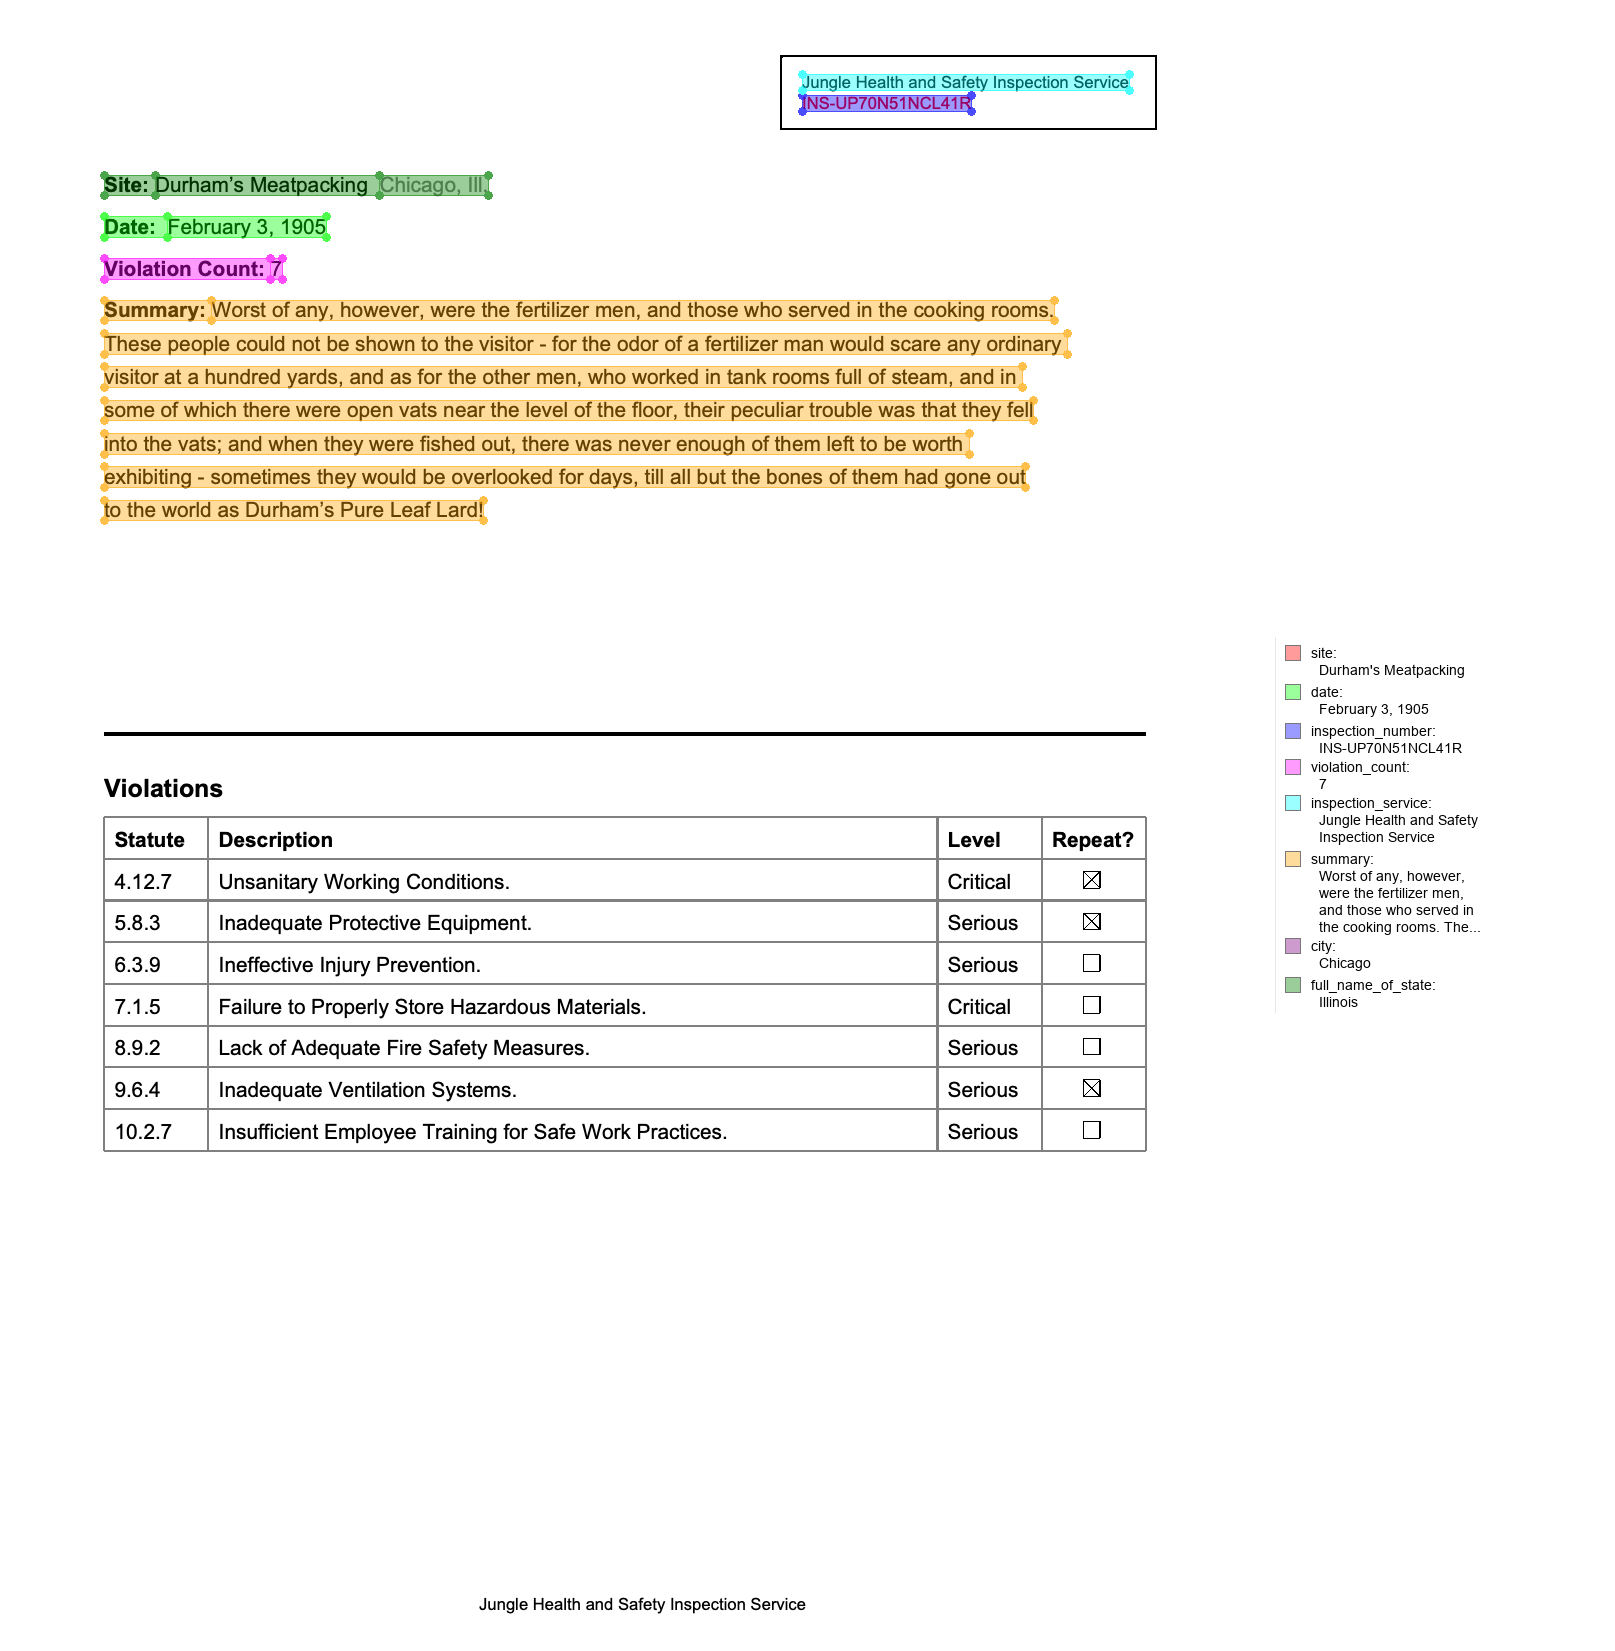

In [13]:
results.show()

### Very intense structured data extraction

Instead of being kind of loose and free with what you want, you can also get MUCH fancier and write a Pydantic model. It will not only send the column names you want, but also little descriptions and demands about strings (text), integers, floats and more.

You can find more details [here](https://platform.openai.com/docs/guides/structured-outputs).

In [16]:
import os
from pydantic import BaseModel, Field
from openai import OpenAI

# Initialize your LLM client
# Anything OpenAI-compatible works!
client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

# Define your schema
class ReportInfo(BaseModel):
    inspection_number: str = Field(description="The main report identifier")
    inspection_date: str = Field(description="The name of the issuing company")
    inspection_service: str = Field(description="Name of inspection service")
    site: str = Field(description="Name of company inspected")
    summary: str = Field(description="Visit summary")
    city: str
    state: str = Field(description="Full name of state")
    violation_count: int

# Extract data
result = page.extract(schema=ReportInfo, client=client, model="gemini-3.1-flash-lite") 

In [17]:
result

StructuredDataResult(inspection_number='INS-UP70N51NCL41R', inspection_date='February 3, 1905', inspection_service='Jungle Health and Safety Inspection Service', ...)

There are a handful of ways to access the results.

In [18]:
result.to_dict()['inspection_date']

'February 3, 1905'

In [19]:
result['inspection_date'].value

'February 3, 1905'

In [20]:
result.data.inspection_date

'February 3, 1905'

## Table extraction with LLMs

In the example below, we're saying "Using Gemini, provide a violations table - each row should have a statute, a description, a level, and a repeat-checked

In [22]:
import os
from pydantic import BaseModel, Field
from openai import OpenAI
from typing import List, Literal

client = OpenAI(
    api_key=GOOGLE_API_KEY,
    # api_key="YOUR_API_KEY_HERE",
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/"
)

class ViolationsRow(BaseModel):
    statute: str
    description: str
    level: str
    repeat_checked: Literal["checked", "unchecked"] = Field("Whether the checkbox is checked or not")

class ViolationsTable(BaseModel):
    inspection_id: str
    violations: List[ViolationsRow]

result = page.extract(schema=ViolationsTable, client=client, model="gemini-3.1-flash-lite") 
result

StructuredDataResult(inspection_id='INS-UP70N51NCL41R', violations=[{'statute': '4.12.7', 'description': 'Unsanitary Working Conditions.', 'level': 'Critical', 'repeat_checked': 'unchecked'}, {'statute': '5.8.3', 'description': 'Inadequate Protective Equipment.', 'level': 'Serious', 'repeat_checked': 'unchecked'}, {'statute': '6.3.9', 'description': 'Ineffective Injury Prevention.', 'level': 'Serious', 'repeat_checked': 'unchecked'}, {'statute': '7.1.5', 'description': 'Failure to Properly Store Hazardous Materials.', 'level': 'Critical', 'repeat_checked': 'unchecked'}, {'statute': '8.9.2', 'description': 'Lack of Adequate Fire Safety Measures.', 'level': 'Serious', 'repeat_checked': 'unchecked'}, {'statute': '9.6.4', 'description': 'Inadequate Ventilation Systems.', 'level': 'Serious', 'repeat_checked': 'unchecked'}, {'statute': '10.2.7', 'description': 'Insufficient Employee Training for Safe Work Practices.', 'level': 'Serious', 'repeat_checked': 'unchecked'}])

Note that when we look below... **it didn't do the checked/unchecked correctly!**

In [23]:
import pandas as pd

violations = result.to_dict()['violations']
pd.DataFrame(violations)

,statute,description,level,repeat_checked
0,4.12.7,Unsanitary Working Conditions.,Critical,unchecked
1,5.8.3,Inadequate Protective Equipment.,Serious,unchecked
2,6.3.9,Ineffective Injury Prevention.,Serious,unchecked
3,7.1.5,Failure to Properly Store Hazardous Materials.,Critical,unchecked
4,8.9.2,Lack of Adequate Fire Safety Measures.,Serious,unchecked
5,9.6.4,Inadequate Ventilation Systems.,Serious,unchecked
6,10.2.7,Insufficient Employee Training for Safe Work P...,Serious,unchecked


**This is why you can't trust LLMs**. When possible, extracting specifically from the page – especially with numbers! – is always your best approach.

# Putting things in categories

Sometimes you have documents that might fall into various categories - is it a police report? An interview transcript? A photograph? Whether you need to categorize based on how something *looks* or the text inside of it, Natural PDF has you covered!

## Categorizing an entire PDF

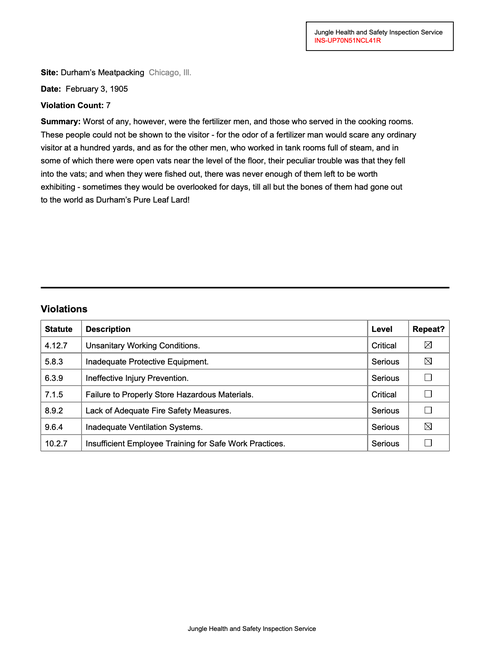

In [24]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/01-practice.pdf")
page = pdf.pages[0]
page.show(width=500)

What can we classify the entire PDF as? Maybe a... slaughterhouse report? A dolphin training manual? Something about basketball or birding?

In [25]:
pdf.classify(['slaughterhouse report', 'dolphin training manual', 'basketball', 'birding'], using='text')
pdf.category

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

'slaughterhouse report'

In [26]:
pdf.category_confidence

0.8695738911628723

## Classifying pages of a PDF

Let's take a look at a document from the CIA investigating whether you can **use pigeons as spies**.

Could get FontBBox from font descriptor because None cannot be parsed as 4 floats


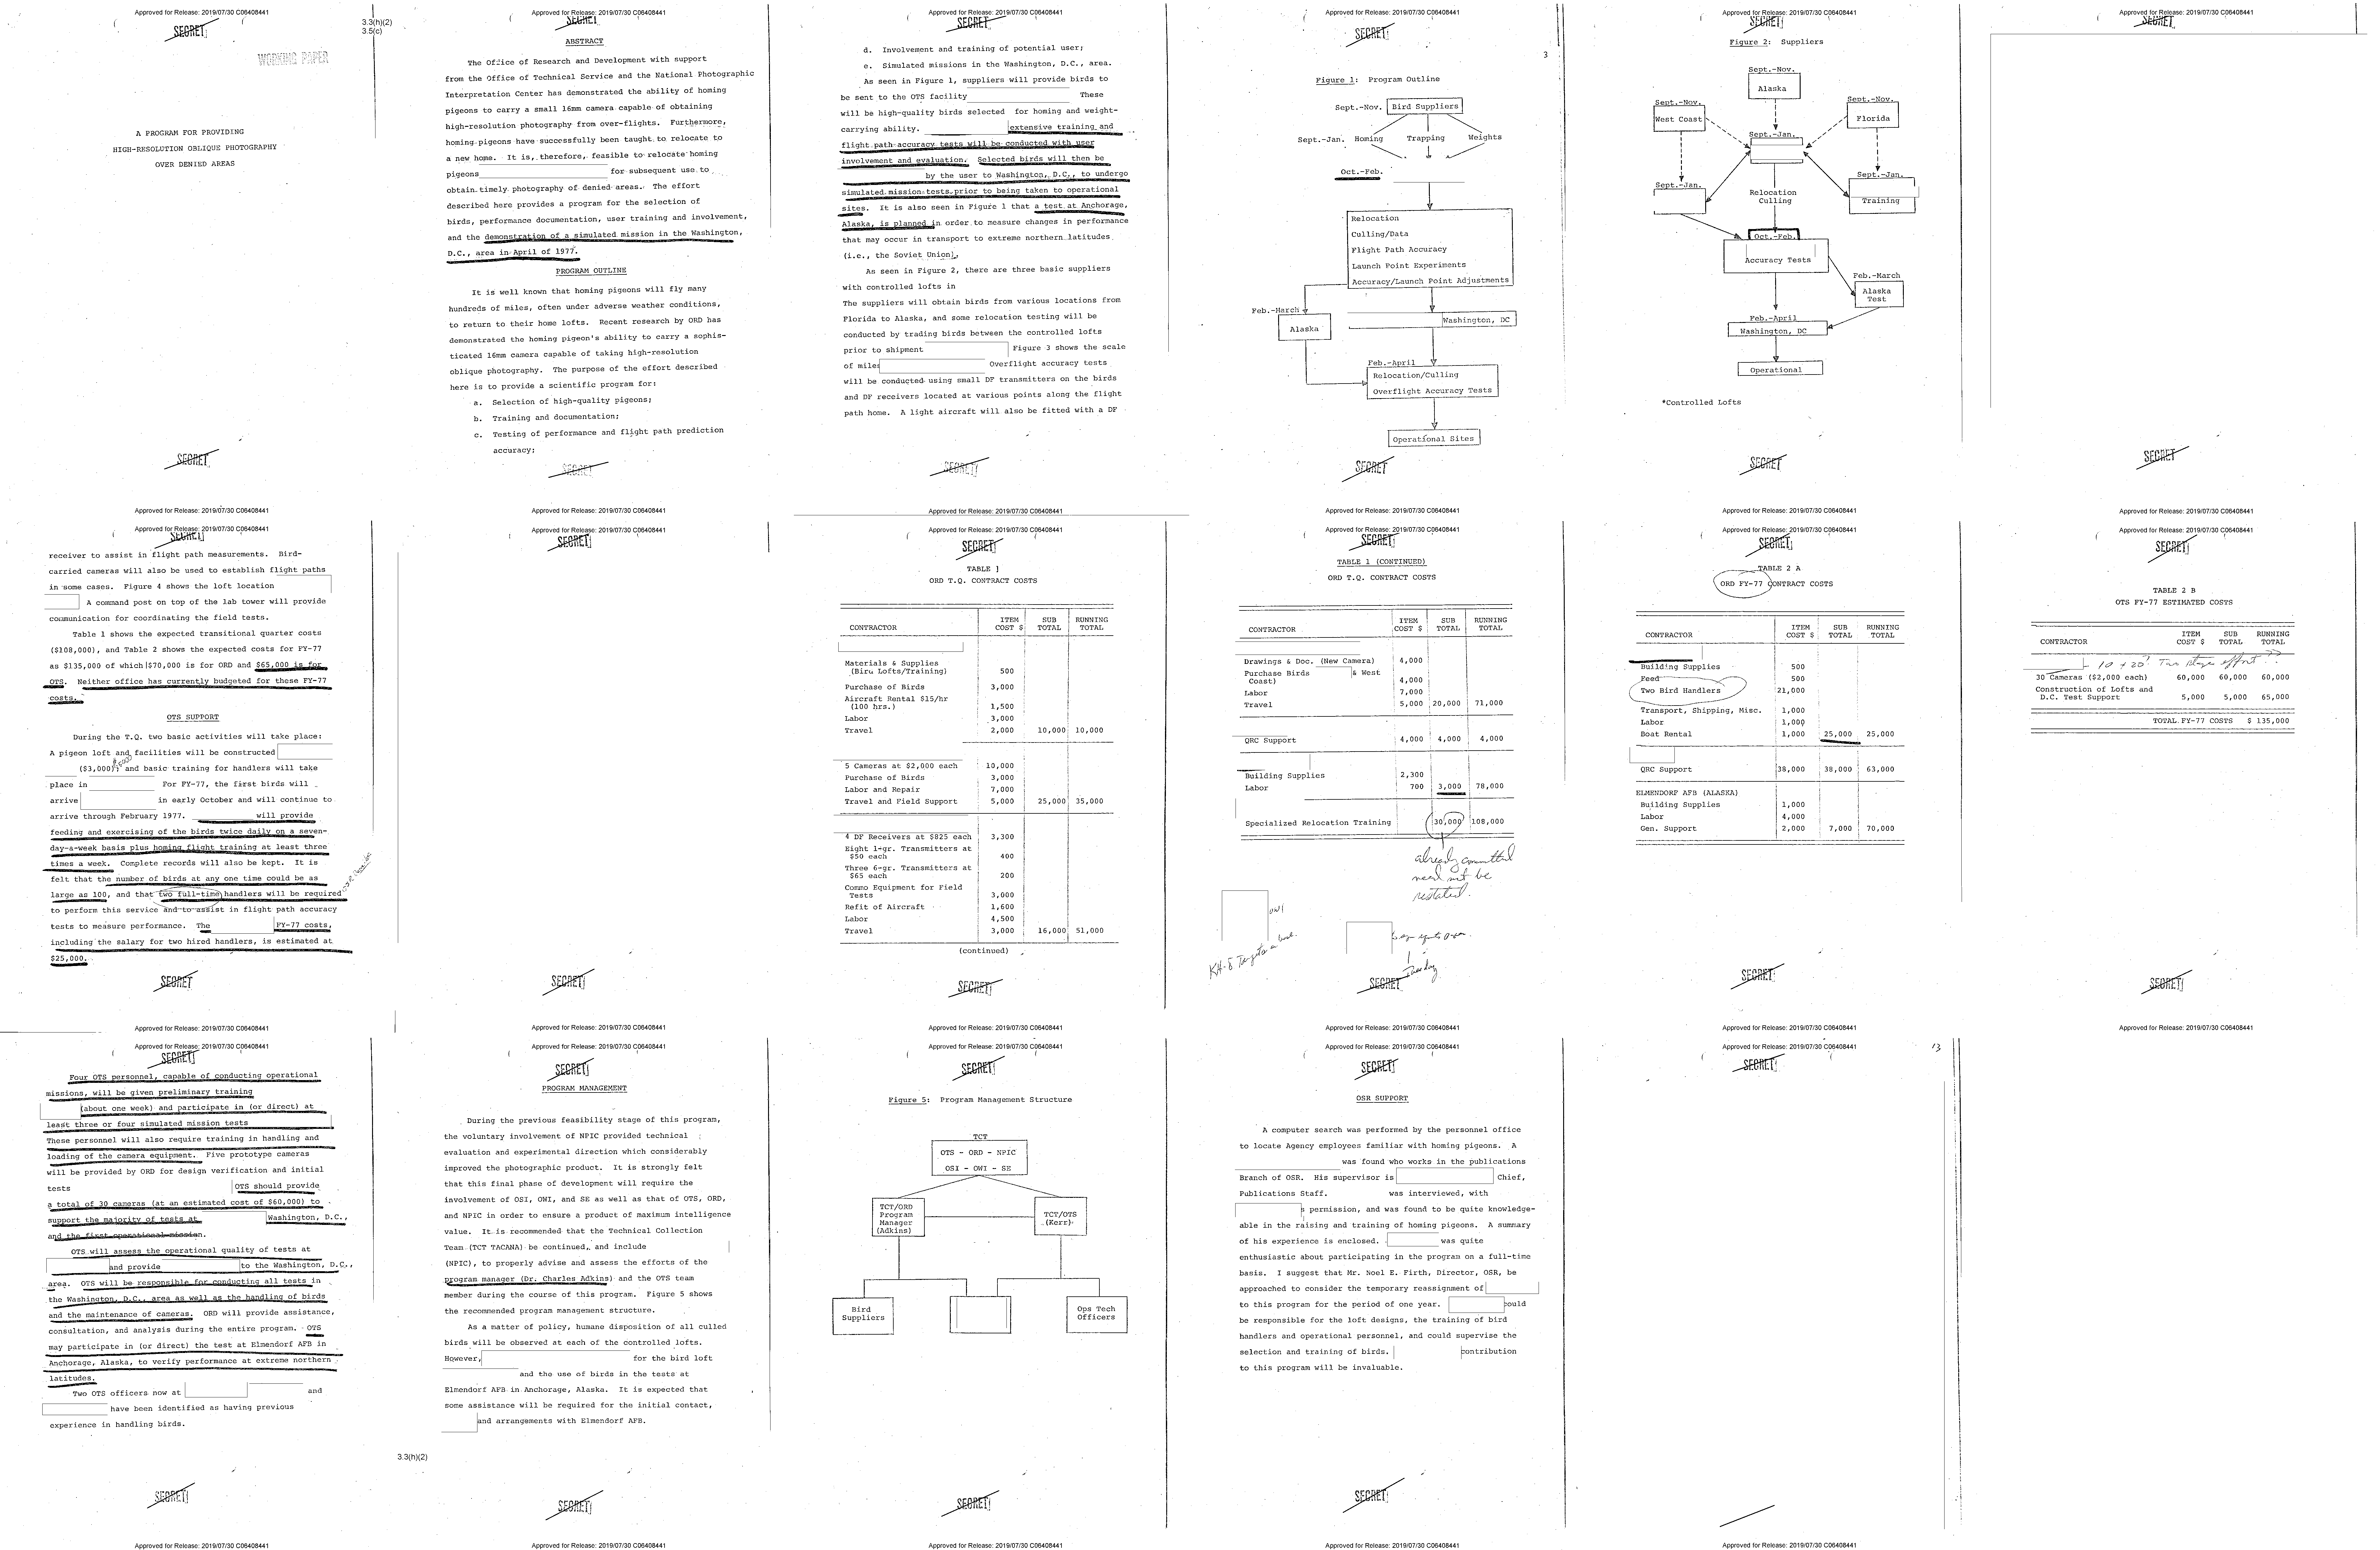

In [27]:
from natural_pdf import PDF

pdf = PDF("https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/cia-doc.pdf")
pdf.pages.show(cols=6)

Just like we did above, we can ask what category we think the PDF belongs to.

In [28]:
pdf.classify(['slaughterhouse report', 'dolphin training manual', 'basketball', 'birding'], using='text')
(pdf.category, pdf.category_confidence)

('birding', 0.5170512795448303)

But notice how all of the pages look very very different: **we can also categorize each page using vision**.

In [29]:
pdf.classify_pages(['diagram', 'text', 'invoice', 'blank'], using='vision')

for page in pdf.pages:
    print(f"Page {page.number} is {page.category} - {page.category_confidence:0.3}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Classifying batch (openai/clip-vit-base-patch16):   0%|          | 0/17 [00:00<?, ?it/s]

Page 1 is invoice - 0.508
Page 2 is text - 0.968
Page 3 is text - 0.953
Page 4 is diagram - 0.903
Page 5 is diagram - 0.907
Page 6 is invoice - 0.969
Page 7 is text - 0.887
Page 8 is invoice - 0.79
Page 9 is invoice - 0.975
Page 10 is invoice - 0.984
Page 11 is invoice - 0.994
Page 12 is invoice - 0.987
Page 13 is text - 0.88
Page 14 is text - 0.928
Page 15 is diagram - 0.927
Page 16 is text - 0.82
Page 17 is invoice - 0.947


Page 1 is invoice - 0.508
Page 2 is text - 0.968
Page 3 is text - 0.953
Page 4 is diagram - 0.904
Page 5 is diagram - 0.907
Page 6 is invoice - 0.969
Page 7 is text - 0.887
Page 8 is invoice - 0.79
Page 9 is invoice - 0.975
Page 10 is invoice - 0.984
Page 11 is invoice - 0.994
Page 12 is invoice - 0.987
Page 13 is text - 0.88
Page 14 is text - 0.928
Page 15 is diagram - 0.927
Page 16 is text - 0.82
Page 17 is invoice - 0.947


And if we just want to see the pages that are diagrams, we can `.filter` for them.

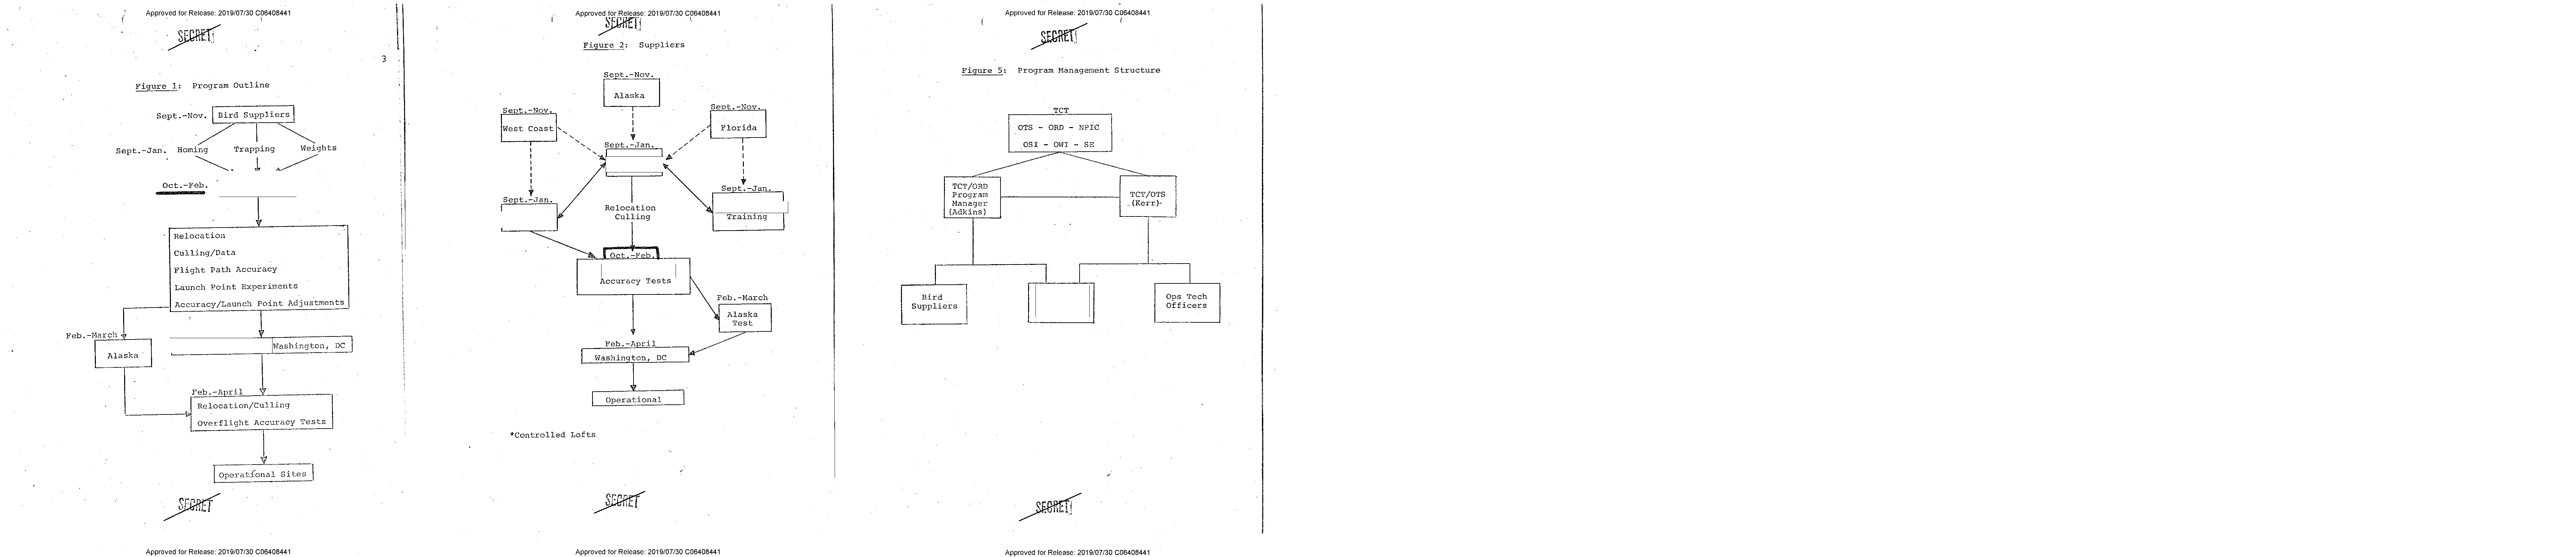

In [30]:
(
    pdf.pages
    .filter(lambda page: page.category == 'diagram')
    .show(show_category=True)
)


And if that's all we're interested in? We can save a new PDF of just those pages!

In [31]:
(
    pdf.pages
    .filter(lambda page: page.category == 'diagram')
    .save_pdf("diagrams.pdf", original=True)
)